<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [1]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -----------------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Usuário\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris.data  
y = iris.target 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Tamanho do treino: {len(y_train)}")
print(f"Tamanho do teste: {len(y_test)}")


Tamanho do treino: (120,)
Tamanho do teste: (30,)


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred_test)

print(f"Acurácia no Treino: {acc_train:.4f}")
print(f"Acurácia no Teste: {acc_test:.4f}")

Acurácia no Treino: 1.0000
Acurácia no Teste: 0.9333


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

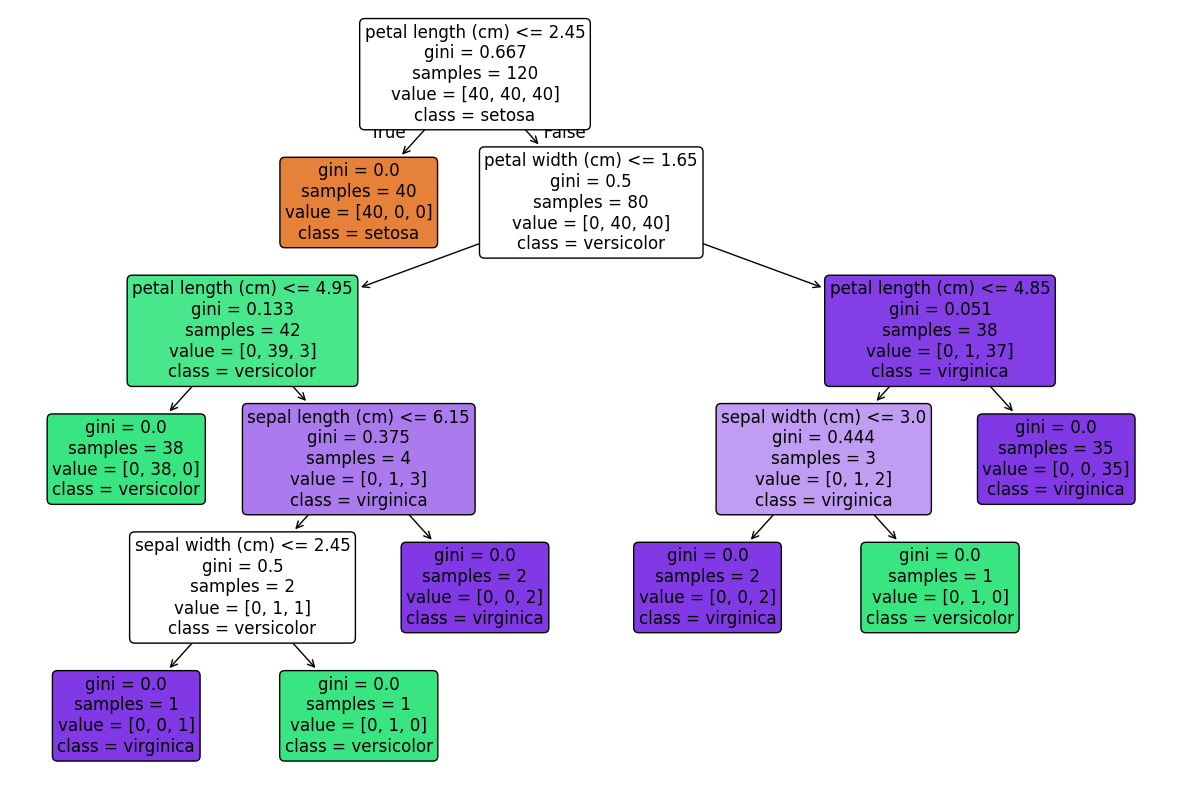

In [14]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))

plot_tree(model, 
          feature_names=iris.feature_names, 
          class_names=iris.target_names, 
          filled=True, 
          rounded=True)

plt.show()


**Solução**.
1. Qual atributo aparece na raiz?

O atributo que aparece na raiz é o pental length (cm) <= 2.45

2. Qual é a profundidade da árvore?

A profundidade da árvore é 5

# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [15]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths = list(range(1, 10)) + [None]
resultados = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    
    acc_treino = accuracy_score(y_train, clf.predict(X_train))
    acc_teste = accuracy_score(y_test, clf.predict(X_test))
    
    profundidade_real = clf.get_depth()
    num_folhas = clf.get_n_leaves()
    
    resultados.append({
        "Max Depth Param": "None" if d is None else d,
        "Profundidade Real": profundidade_real,
        "Número de Folhas": num_folhas,
        "Acurácia Treino": f"{acc_treino:.4f}",
        "Acurácia Teste": f"{acc_teste:.4f}"
    })

df_comparativo = pd.DataFrame(resultados)
df_comparativo

,Max Depth Param,Profundidade Real,Número de Folhas,Acurácia Treino,Acurácia Teste
0,1,1,2,0.6667,0.6667
1,2,2,3,0.9667,0.9333
2,3,3,5,0.9833,0.9667
3,4,4,7,0.9917,0.9333
4,5,5,8,1.0000,0.9333
5,6,5,8,1.0000,0.9333
6,7,5,8,1.0000,0.9333
7,8,5,8,1.0000,0.9333
8,9,5,8,1.0000,0.9333
9,None,5,8,1.0000,0.9333


**Em qual profundidade começa o overfitting?**

O overfitting começa na profundidade 4, pois a acurácia do teste acaba diminuindo para poder melhorar a acurácia do treino

**Por que a árvore consegue 100% no treino quando max_depth=None?**

Isso acontece porquem sem um limite de profundidade para a árvore ela vai continuar dividindo ate que todas os nós finais(folhas) se tornem puros


# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

criterios = ["gini", "entropy"]
resultados_q5 = []

for crit in criterios:
    clf = DecisionTreeClassifier(criterion=crit, random_state=42)
    clf.fit(X_train, y_train)
    
    acc_treino = accuracy_score(y_train, clf.predict(X_train))
    acc_teste = accuracy_score(y_test, clf.predict(X_test))
    profundidade = clf.get_depth()
    
    resultados_q5.append({
        "Critério": crit,
        "Profundidade": profundidade,
        "Acurácia Treino": f"{acc_treino:.4f}",
        "Acurácia Teste": f"{acc_teste:.4f}"
    })

df_q5 = pd.DataFrame(resultados_q5)
df_q5

,Critério,Profundidade,Acurácia Treino,Acurácia Teste
0,gini,5,1.0000,0.9333
1,entropy,5,1.0000,0.9333


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

   min_samples_split  Acurácia Treino  Acurácia Teste  Profundidade
0                  2         1.000000        0.933333             5
1                  5         0.983333        0.966667             3
2                 10         0.983333        0.966667             3
3                 20         0.983333        0.966667             3
4                 30         0.983333        0.966667             3
5                 40         0.983333        0.966667             3
6                 50         0.966667        0.933333             2


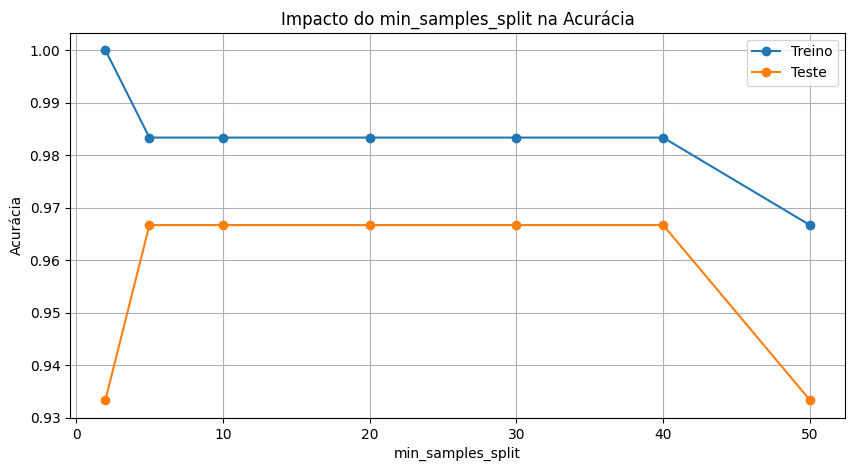

In [ ]:
import matplotlib.pyplot as plt

split_values = [2, 5, 10, 20, 30, 40, 50]
resultados_q6 = []

for val in split_values:
    clf = DecisionTreeClassifier(min_samples_split=val, random_state=42)
    clf.fit(X_train, y_train)
    
    acc_treino = accuracy_score(y_train, clf.predict(X_train))
    acc_teste = accuracy_score(y_test, clf.predict(X_test))
    
    resultados_q6.append({
        "min_samples_split": val,
        "Acurácia Treino": acc_treino,
        "Acurácia Teste": acc_teste,
        "Profundidade": clf.get_depth()
    })

df_q6 = pd.DataFrame(resultados_q6)
print(df_q6)

plt.figure(figsize=(10, 5))
plt.plot(df_q6['min_samples_split'], df_q6['Acurácia Treino'], label='Treino', marker='o')
plt.plot(df_q6['min_samples_split'], df_q6['Acurácia Teste'], label='Teste', marker='o')
plt.title('Impacto do min_samples_split na Acurácia')
plt.xlabel('min_samples_split')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)
plt.show()